# Predictive Modeling for Network Intrusion Detection

## Internship Project

### Dataset: CICIDS2017

In [1]:
from google.colab import files

uploaded = files.upload()

Saving cicids2017_cleaned.csv to cicids2017_cleaned.csv


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("cicids2017_cleaned.csv")

In [6]:
import os

os.listdir()

['.config', 'cicids2017_cleaned.csv', 'sample_data']

In [7]:
df = pd.read_csv("cicids2017_cleaned.csv")
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [8]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [9]:
df.shape

(2520751, 53)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520751 entries, 0 to 2520750
Data columns (total 53 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Length of Fwd Packets  int64  
 4   Fwd Packet Length Max        int64  
 5   Fwd Packet Length Min        int64  
 6   Fwd Packet Length Mean       float64
 7   Fwd Packet Length Std        float64
 8   Bwd Packet Length Max        int64  
 9   Bwd Packet Length Min        int64  
 10  Bwd Packet Length Mean       float64
 11  Bwd Packet Length Std        float64
 12  Flow Bytes/s                 float64
 13  Flow Packets/s               float64
 14  Flow IAT Mean                float64
 15  Flow IAT Std                 float64
 16  Flow IAT Max                 int64  
 17  Flow IAT Min                 int64  
 18  Fwd IAT Total                int64  
 19  

In [11]:
df.isnull().sum()

,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Length of Fwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0
Bwd Packet Length Max,0
Bwd Packet Length Min,0


In [12]:
df.dropna(inplace=True)

In [13]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Length of Fwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_p

In [15]:
df.columns.tolist()

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Length of Fwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'Average Packet Size',
 'Subflow Fwd Bytes',
 'Init_Win_bytes_forward',
 'Init_Win_bytes_backward',
 'act_data_pkt_fwd',
 'min_seg_size_forward',
 'Active Mean',
 'Active M

In [16]:
df.columns = df.columns.str.strip()

In [17]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Length of Fwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_p

In [18]:
df.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
2520746,53,32215,4,112,28,28,28.0,0.00000,76,76,...,-1,3,20,0.0,0,0,0.0,0,0,Normal Traffic
2520747,53,324,2,84,42,42,42.0,0.00000,181,181,...,-1,1,20,0.0,0,0,0.0,0,0,Normal Traffic
2520748,58030,82,2,31,31,0,15.5,21.92031,6,6,...,0,0,32,0.0,0,0,0.0,0,0,Normal Traffic
2520749,53,1048635,6,192,32,32,32.0,0.00000,128,128,...,-1,5,20,0.0,0,0,0.0,0,0,Normal Traffic
2520750,53,94939,4,188,47,47,47.0,0.00000,113,113,...,-1,3,20,0.0,0,0,0.0,0,0,Normal Traffic


In [19]:
df.dtypes

,0
Destination Port,int64
Flow Duration,int64
Total Fwd Packets,int64
Total Length of Fwd Packets,int64
Fwd Packet Length Max,int64
Fwd Packet Length Min,int64
Fwd Packet Length Mean,float64
Fwd Packet Length Std,float64
Bwd Packet Length Max,int64
Bwd Packet Length Min,int64


In [20]:
df['Attack Type'].value_counts()

,count
Attack Type,
Normal Traffic,2095057
DoS,193745
DDoS,128014
Port Scanning,90694
Brute Force,9150
Web Attacks,2143
Bots,1948


In [21]:
df.isnull().sum()

,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Length of Fwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0
Bwd Packet Length Max,0
Bwd Packet Length Min,0


In [22]:
df.duplicated().sum()

np.int64(161)

In [23]:
df.drop_duplicates(inplace=True)

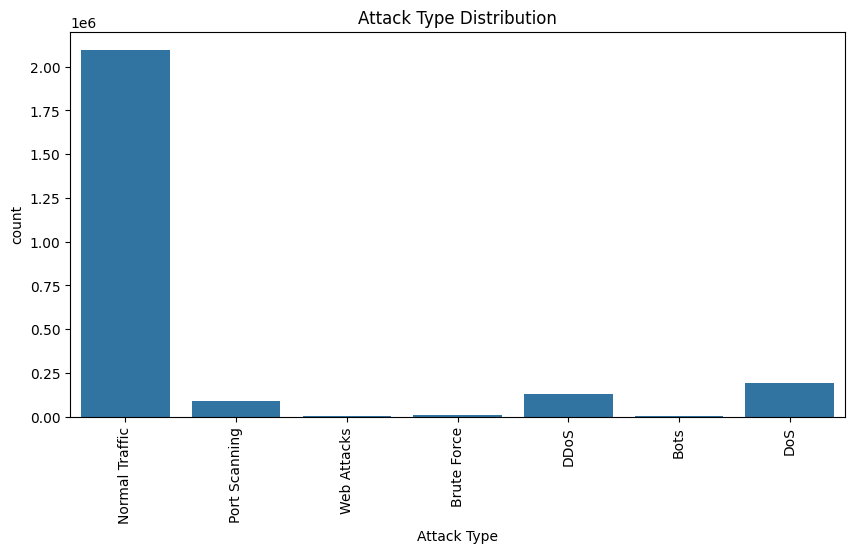

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Attack Type',
    data=df
)

plt.xticks(rotation=90)
plt.title("Attack Type Distribution")
plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Attack Type'] = le.fit_transform(df['Attack Type'])

In [26]:
df['Attack Type'].value_counts()

,count
Attack Type,
4,2094896
3,193745
2,128014
5,90694
1,9150
6,2143
0,1948


In [27]:
X = df.drop('Attack Type', axis=1)

y = df['Attack Type']

In [28]:
X.shape, y.shape

((2520590, 52), (2520590,))

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
X_train.shape, X_test.shape

((2016472, 52), (504118, 52))

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_scaled,
    y_train
)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [33]:
y_pred = rf_model.predict(X_test_scaled)

In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9985439916844866


In [35]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.73      0.80       389
           1       1.00      1.00      1.00      1830
           2       1.00      1.00      1.00     25603
           3       1.00      1.00      1.00     38749
           4       1.00      1.00      1.00    418979
           5       0.99      0.99      0.99     18139
           6       0.99      0.97      0.98       429

    accuracy                           1.00    504118
   macro avg       0.98      0.95      0.97    504118
weighted avg       1.00      1.00      1.00    504118



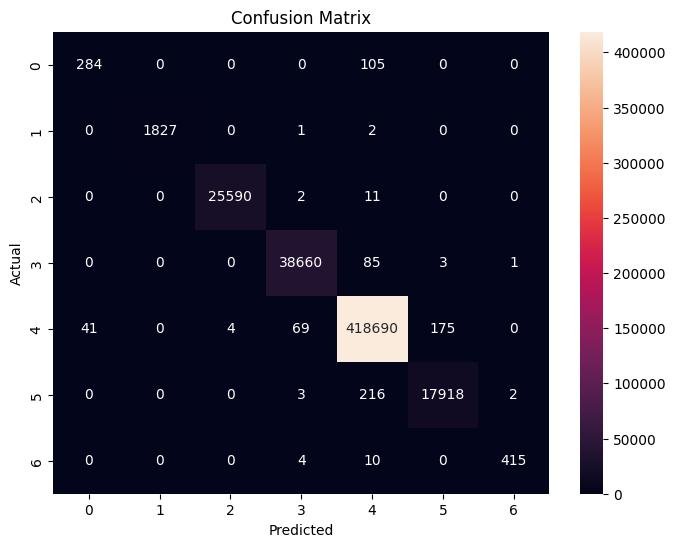

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [37]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
11,Bwd Packet Length Std,0.085269
36,Packet Length Variance,0.082868
35,Packet Length Std,0.060140
40,Average Packet Size,0.051546
33,Max Packet Length,0.045085
10,Bwd Packet Length Mean,0.043665
41,Subflow Fwd Bytes,0.041342
3,Total Length of Fwd Packets,0.040002
34,Packet Length Mean,0.039817
4,Fwd Packet Length Max,0.033019


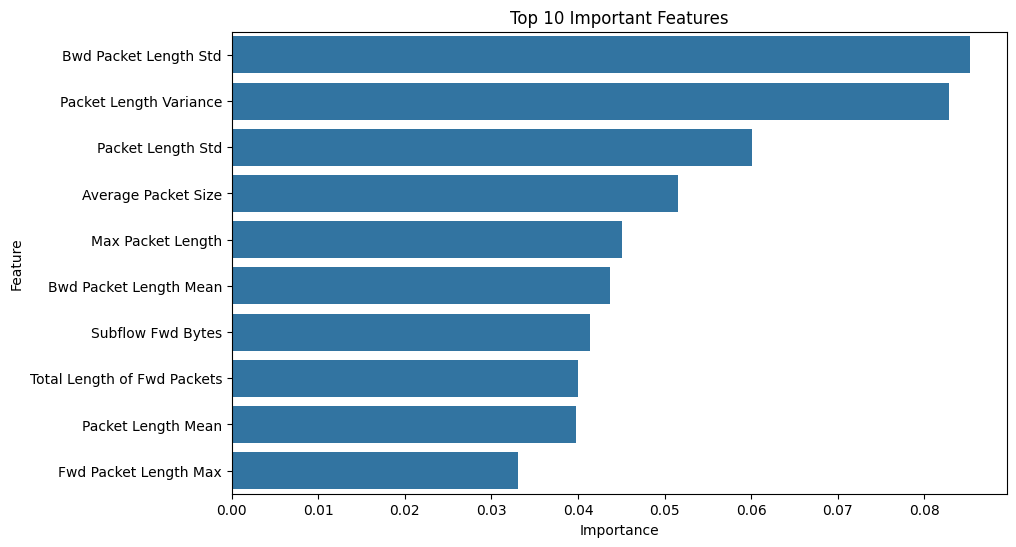

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

In [39]:
import joblib

joblib.dump(
    rf_model,
    "network_intrusion_detection_model.pkl"
)

['network_intrusion_detection_model.pkl']

In [40]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

## Project Results

- Dataset: CICIDS2017
- Algorithm Used: Random Forest Classifier
- Features Used: 52 network traffic features
- Task: Multi-class Network Intrusion Detection

The model successfully classified normal and malicious network traffic.
Data preprocessing, feature scaling, and model evaluation were performed.
Performance was evaluated using accuracy, classification report, and confusion matrix.

The developed machine learning model can be used for predictive network intrusion detection systems.